In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from pydsstools.heclib.dss import HecDss

dss_path = Path(
    r"C:\Users\jo487\Desktop\pywr_russian"
    r"\RussianRiver_UWMP_2025\rss\2025_UWMP\simulation.dss"
)

with HecDss.Open(str(dss_path), mode="r") as fid:
    paths = fid.search_path(sort=True)

hopland_paths = [
    pathname
    for pathname in paths
    if "HOPLAND" in pathname.upper()
]

print("Total records:", len(paths))
print("Hopland records:", len(hopland_paths))

for pathname in hopland_paths:
    print(pathname)

Traceback (most recent call last):
  File "c:\Users\jo487\AppData\Local\miniconda3\envs\whipgen\Lib\site-packages\pydsstools\core\raster_grid.py", line 18, in <module>
    import rasterio
ModuleNotFoundError: No module named 'rasterio'


Total records: 71352
Hopland records: 5130
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1910/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1911/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1912/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1913/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1914/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1915/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1916/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1917/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1918/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1919/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1920/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1921/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1922/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1923/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1924/1DAY/UWMP_25BAS0/
//2025BO-MIN1-HOPLAND/FLOW-SPACE/01JAN1925

In [5]:
dss_path = Path(
    r"C:\Users\jo487\Desktop\pywr_russian"
    r"\RussianRiver_UWMP_2025\rss\2025_UWMP\simulation.dss"
)

paths = {
    "Cloverdale Local": "//CLOVERDALE/FLOW-LOCAL//1DAY/UWMP_25BAS0/",
    "Healdsburg Local": "//HEALDSBURG/FLOW-LOCAL//1DAY/UWMP_25BAS0/",
    "Cloverdale CUMLOC": "//CLOVERDALE/FLOW-CUMLOC//1DAY/UWMP_25BAS0/",
    "Healdsburg CUMLOC": "//HEALDSBURG/FLOW-CUMLOC//1DAY/UWMP_25BAS0/",
}


def read_series(fid, pathname, name):
    ts = fid.read_ts(pathname, trim_missing=True)

    if hasattr(ts, "pytimes"):
        times = ts.pytimes
    else:
        times = [time.datetime() for time in ts.times]

    return pd.Series(
        ts.values,
        index=pd.to_datetime(times),
        name=name,
        dtype=float,
    )


with HecDss.Open(str(dss_path), mode="r") as fid:
    series = {
        name: read_series(fid, pathname, name)
        for name, pathname in paths.items()
    }

df = pd.concat(series.values(), axis=1, sort=False).dropna().sort_index()

# Correct two-day routing balance
df["Cloverdale CUMLOC lagged 2 days"] = df["Cloverdale CUMLOC"].shift(2)

df["Healdsburg reconstructed"] = (
    df["Cloverdale CUMLOC lagged 2 days"]
    + df["Healdsburg Local"]
)

df["Residual"] = (
    df["Healdsburg CUMLOC"]
    - df["Healdsburg reconstructed"]
)

balance = df.dropna()

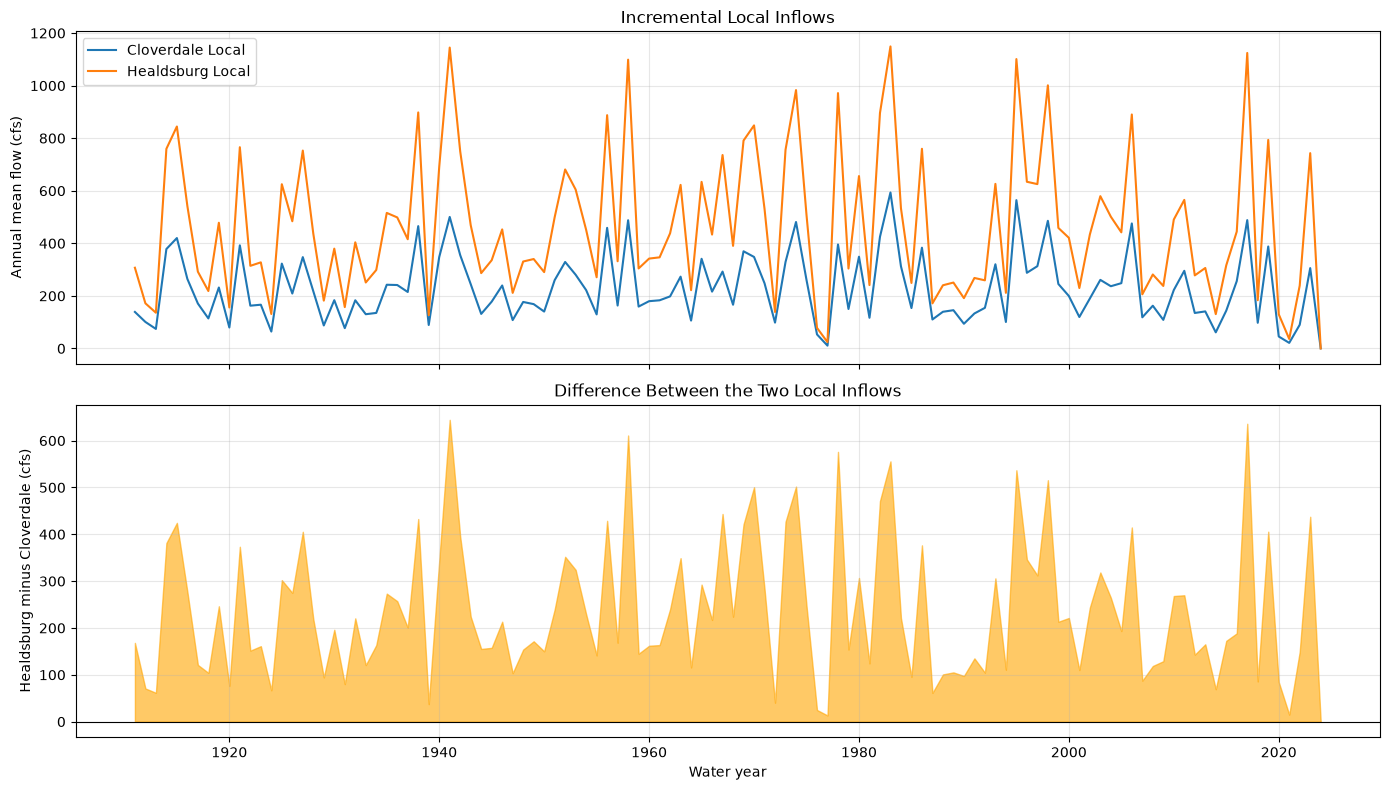

Cloverdale mean: 227.48735570964777 cfs
Healdsburg mean: 464.3045236239057 cfs
Mean ratio: 2.0410124429795484
Correlation: 0.9851538502864061


In [4]:
local = df[["Cloverdale Local", "Healdsburg Local"]].dropna().copy()

local["Water Year"] = (
    local.index.year
    + (local.index.month >= 10).astype(int)
)

annual = local.groupby("Water Year")[
    ["Cloverdale Local", "Healdsburg Local"]
].mean()

annual["Difference"] = (
    annual["Healdsburg Local"]
    - annual["Cloverdale Local"]
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    annual.index,
    annual["Cloverdale Local"],
    label="Cloverdale Local",
)
axes[0].plot(
    annual.index,
    annual["Healdsburg Local"],
    label="Healdsburg Local",
)
axes[0].set_ylabel("Annual mean flow (cfs)")
axes[0].set_title("Incremental Local Inflows")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].fill_between(
    annual.index,
    0,
    annual["Difference"],
    color="orange",
    alpha=0.6,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Healdsburg minus Cloverdale (cfs)")
axes[1].set_xlabel("Water year")
axes[1].set_title("Difference Between the Two Local Inflows")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "Cloverdale mean:",
    annual["Cloverdale Local"].mean(),
    "cfs",
)
print(
    "Healdsburg mean:",
    annual["Healdsburg Local"].mean(),
    "cfs",
)
print(
    "Mean ratio:",
    annual["Healdsburg Local"].mean()
    / annual["Cloverdale Local"].mean(),
)
print(
    "Correlation:",
    annual["Cloverdale Local"].corr(
        annual["Healdsburg Local"]
    ),
)

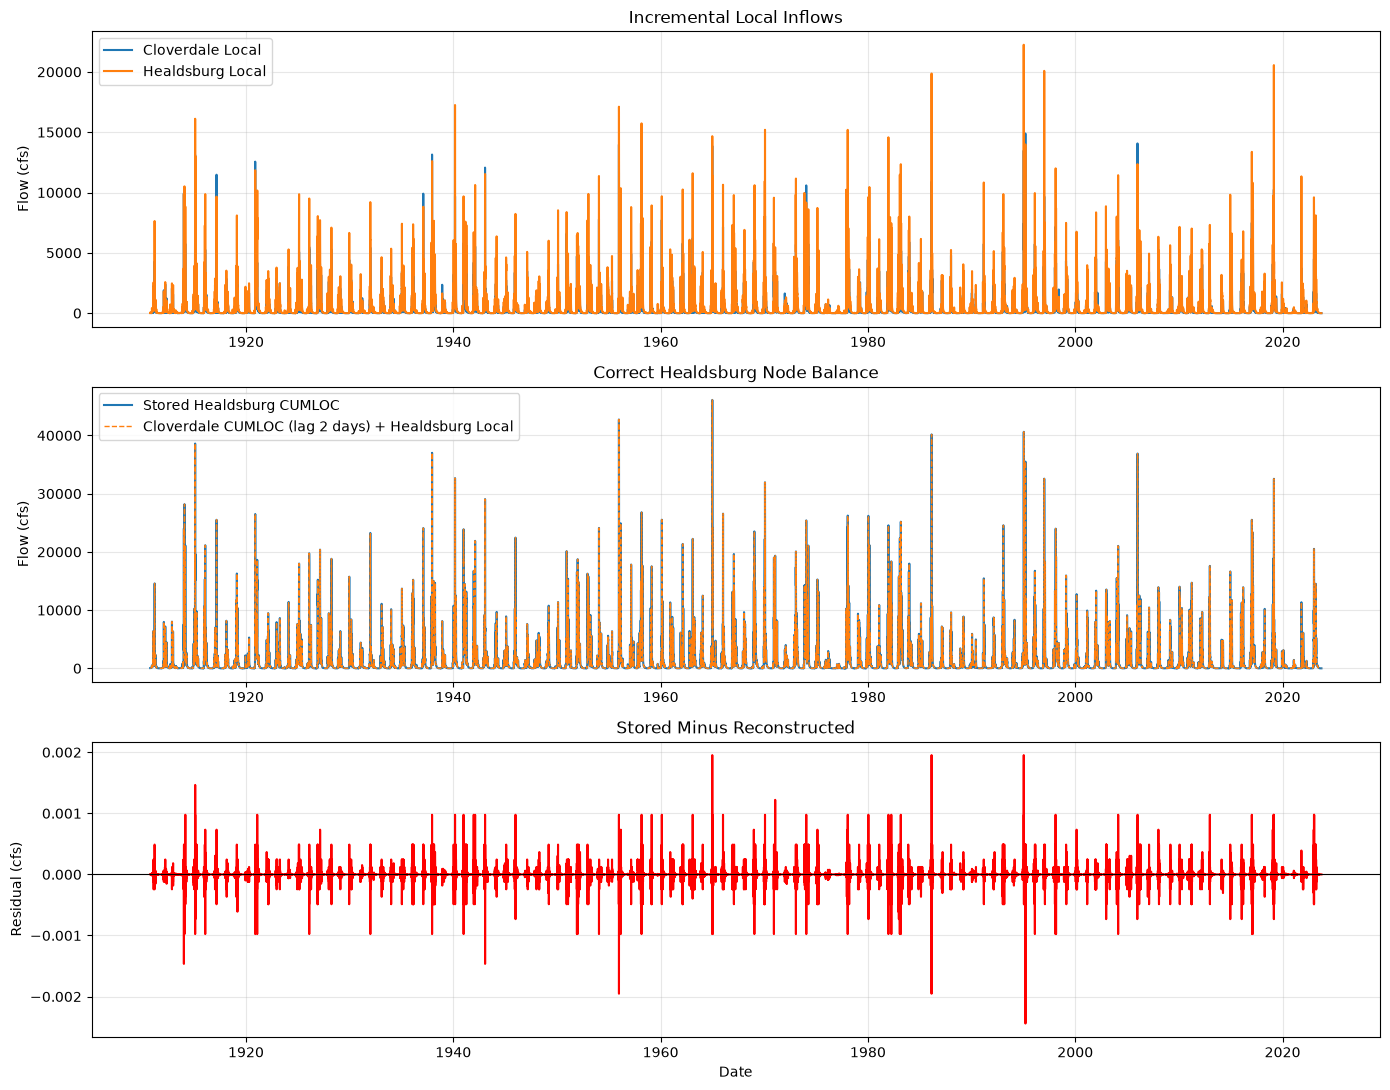

Number of days: 41271
Maximum absolute residual: 0.00244140625 cfs
Mean absolute residual: 2.48137209873602e-05 cfs


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

axes[0].plot(df.index, df["Cloverdale Local"], label="Cloverdale Local")
axes[0].plot(df.index, df["Healdsburg Local"], label="Healdsburg Local")
axes[0].set_title("Incremental Local Inflows")
axes[0].set_ylabel("Flow (cfs)")
axes[0].legend()

# node-balance comparison
axes[1].plot(
    balance.index,
    balance["Healdsburg CUMLOC"],
    label="Stored Healdsburg CUMLOC",
    linewidth=1.5,
)
axes[1].plot(
    balance.index,
    balance["Healdsburg reconstructed"],
    "--",
    label="Cloverdale CUMLOC (lag 2 days) + Healdsburg Local",
    linewidth=1,
)
axes[1].set_title("Correct Healdsburg Node Balance")
axes[1].set_ylabel("Flow (cfs)")
axes[1].legend()

# Difference
axes[2].plot(balance.index, balance["Residual"], color="red")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Stored Minus Reconstructed")
axes[2].set_ylabel("Residual (cfs)")
axes[2].set_xlabel("Date")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Number of days:", len(balance))
print("Maximum absolute residual:", balance["Residual"].abs().max(), "cfs")
print("Mean absolute residual:", balance["Residual"].abs().mean(), "cfs")